# Neural geometry of interaction: solving sudokus by message passing

This notebook demonstrates `discopy.neural`, the compact closed category of
**bidirectional neural networks**:

* objects are *additive* dimensions `Dim(a, b, ...)` — networks compose with
  the cartesian product of vector spaces, so the tensor of dimensions is
  their sum and the unit is the zero-dimensional space `Dim(0)`,
* a box `Network('f', Dim(a), Dim(b))` carries one torch module
  $\mathbb{R}^{a+b} \to \mathbb{R}^{a+b}$ which reads an incoming message on
  *every* port (domain and codomain alike) and emits an outgoing message on
  every port,
* dimensions are self-dual, so cups, caps and swaps are pure rerouting.

The combinatorial maps of this category are **graph neural networks**: message
passing along the wires implements the *execution formula* of the geometry of
interaction (see Abramsky's *Retracing some paths in process algebra* and
`discopy.interaction` for the Int-construction of Joyal, Street & Verity).

In [1]:
import time
import random

import torch
from discopy.neural import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")
torch.manual_seed(42)


def mlp(width):
    return torch.nn.Sequential(
        torch.nn.Linear(width, 2 * width), torch.nn.Tanh(),
        torch.nn.Linear(2 * width, width))

running on cuda


The sudoku encoding itself is experiment code rather than library code, so it lives in the notebook: `discopy.neural` keeps only the generic categorical machinery (dimensions, networks, combinatorial maps and their message passing), while the helpers below (the grid encoding, a recurrent cell, and the generation, backtracking solver, checker and decoder) stay with the experiment. A cell is *stateless* (feedforward) when it is wired to its peers only, or *stateful* (recurrent) when `state_dim` is set: then every cell also gets a self-wired **state** pair and **clue** pair of ports, i.e. two feedback loops in the sense of the trace.

In [2]:
def sudoku_peers(n=2):
    """Peers of each cell: the cells sharing a row, column or n x n block."""
    size = n * n

    def block(cell):
        return (cell // size // n) * n + (cell % size) // n

    return tuple(tuple(sorted(
        other for other in range(size * size) if other != cell and (
            other // size == cell // size
            or other % size == cell % size
            or block(other) == block(cell))))
        for cell in range(size * size))


def sudoku(n=2, dim=8, state_dim=None, network=None):
    """A sudoku grid as a closed map, one shared cell network per cell.

    With ``state_dim`` set, each cell also carries a self-wired state pair and
    clue pair of ports; its port order is then
    ``[peer_1, ..., peer_P, state, state', clue, clue']``.
    """
    peers = sudoku_peers(n)
    P = len(peers[0])
    if network is None:
        if state_dim is None:
            network = Network('cell', Dim(0), Dim(dim) ** P,
                              module=mlp(P * dim))
        else:
            network = Network(
                'cell', Dim(0),
                Dim(dim) ** P @ Dim(state_dim) ** 2 @ Dim(dim) ** 2,
                module=gru_cell(dim, state_dim))
    wires = [
        ((cell, peers[cell].index(other)), (other, peers[other].index(cell)))
        for cell in range(n ** 4) for other in peers[cell] if cell < other]
    if state_dim is not None:
        for cell in range(n ** 4):
            wires.append(((cell, P), (cell, P + 1)))          # state loop
            wires.append(((cell, P + 2), (cell, P + 3)))      # clue loop
    return CMap.from_wiring(n ** 4 * (network, ), wires)


def gru_cell(dim, state_dim, hidden_dim=None):
    """A permutation-equivariant recurrent cell for the ``state_dim`` wiring.

    It reads its ports as ``[m_1, ..., m_P | h, h' | c, c']``, encodes each
    peer message against the previous state, mean-pools the encodings, runs a
    GRU update from the pooled messages and the clue, then broadcasts the new
    state to the peers and emits it on both state ports (zeros on the clue
    ports, so the injected clue arrives unchanged every round). ``P`` is read
    off the input width, so the same weights run on any grid size.
    """
    hidden_dim = hidden_dim or 2 * state_dim

    class EquivariantGRUCell(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.dim, self.state_dim = dim, state_dim
            self.encode = torch.nn.Sequential(
                torch.nn.Linear(state_dim + dim, hidden_dim),
                torch.nn.ReLU(), torch.nn.Linear(hidden_dim, hidden_dim))
            self.update = torch.nn.GRUCell(hidden_dim + dim, state_dim)
            self.norm = torch.nn.LayerNorm(state_dim)
            self.emit = torch.nn.Linear(state_dim, dim)

        def forward(self, x):
            d, s = self.dim, self.state_dim
            P = (x.shape[-1] - 2 * s - 2 * d) // d
            peers = x[:, :P * d].reshape(-1, P, d)
            state = x[:, P * d:P * d + s]
            clue = x[:, P * d + 2 * s:P * d + 2 * s + d]
            pooled = self.encode(torch.cat([
                state.unsqueeze(1).expand(-1, P, -1), peers], -1)).mean(1)
            state = self.norm(self.update(
                torch.cat([pooled, clue], -1), state))
            return torch.cat([
                self.emit(state).unsqueeze(1).expand(-1, P, -1)
                    .reshape(-1, P * d),
                state, state,
                torch.zeros_like(clue), torch.zeros_like(clue)], -1)

    return EquivariantGRUCell()


def solve_sudoku(grid, n=2, digits=None):
    """Solve a grid by backtracking, with 0 for blanks."""
    size = n * n
    peers = sudoku_peers(n)
    digits = tuple(range(1, size + 1)) if digits is None else digits
    grid = list(grid)

    def fill(cell):
        if cell == size * size:
            return True
        if grid[cell]:
            return all(grid[p] != grid[cell] for p in peers[cell]) \
                and fill(cell + 1)
        for digit in digits:
            if all(grid[p] != digit for p in peers[cell]):
                grid[cell] = digit
                if fill(cell + 1):
                    return True
        grid[cell] = 0
        return False

    return tuple(grid) if fill(0) else None


def random_sudoku(n=2, n_clues=8, seed=0):
    """A random puzzle and its solution: solve a blank grid, then blank cells."""
    size = n * n
    generator = random.Random(seed)
    digits = list(range(1, size + 1))
    generator.shuffle(digits)
    solution = solve_sudoku(size * size * (0, ), n, tuple(digits))
    cells = list(range(size * size))
    generator.shuffle(cells)
    clues = list(solution)
    for cell in cells[:size * size - n_clues]:
        clues[cell] = 0
    return tuple(clues), solution


def check_sudoku(grid, n=2):
    """Whether a completed grid satisfies all the constraints."""
    size = n * n
    peers = sudoku_peers(n)
    return all(d in range(1, size + 1) for d in grid) and all(
        grid[cell] != grid[peer]
        for cell in range(size * size) for peer in peers[cell])


def decode_sudoku(logits, clues, n=2):
    """Keep the clues, take the most likely digit for each blank cell."""
    result = []
    for cell, clue in enumerate(clues):
        if clue:
            result.append(clue)
        else:
            row = list(logits[cell])
            result.append(1 + max(range(len(row)), key=row.__getitem__))
    return tuple(result)

## Bidirectional networks as a compact closed category

Diagrams compose as usual, and the snake equations hold with self-dual
dimensions: transposing the identity yields the identity.

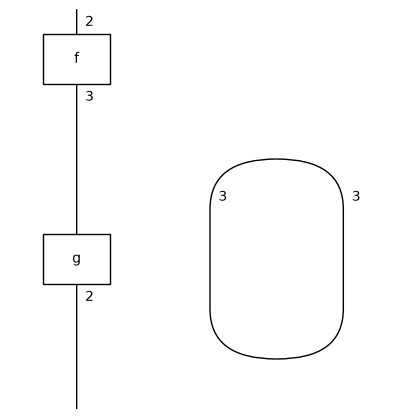

In [3]:
x, y = Dim(2), Dim(3)
f = Network('f', x, y, module=mlp(5))
g = Network('g', y, x, module=mlp(5))

feedback = f @ Cap(y, y) >> g @ Id(y @ y) >> Id(x) @ Cup(y, y)
feedback.draw(figsize=(4, 4))

In [4]:
Diagram.use_hypergraph_equality = True
assert Id(x).transpose() == Id(x) == Id(x).transpose(left=True)
Diagram.use_hypergraph_equality = False

## Message passing is the execution formula

A diagram becomes a combinatorial map with `to_map()`: cups, caps and swaps
dissolve into wiring, only networks remain as boxes. Calling the map runs
synchronous message passing: one message per port, travelling along the wires
each round. For a map with no boxes this is pure rerouting, e.g. the snake
forwards its input unchanged and the swap permutes it.

In [5]:
snake = Id(Dim(2)).transpose().to_map()
assert snake.boxes == ()

point = torch.tensor([[0.1, 0.2]])
assert (snake(point) == point).all()

swap = Diagram.swap(Dim(2), Dim(3)).to_map()
swap(torch.tensor([[1., 2., 3., 4., 5.]]))

tensor([[3., 4., 5., 1., 2.]])

For a map with networks inside, each round every network reads the incoming
messages on all its ports and emits outgoing ones. Boundary inputs are
(re-)delivered every round, so after enough rounds information has crossed
the whole map — this is the trace of the Int-construction, unrolled.

In [6]:
fm = f.to_map()
inputs = torch.rand(1, 2)
assert fm(inputs).shape == (1, 3)

### One flat tensor, one permutation per round

`CMap.forward` is vectorized: it keeps every message in a single flat tensor,
routes them along the wires with one permutation of the last axis, and
evaluates all the cells that share a module and a port signature in **one**
batched call. `CMap.forward_reference` is the readable one-call-per-box
version — same result, but a Python loop over the cells. On a GPU the gap
grows with the grid: the reference pays one kernel launch per cell per round,
the vectorized pass pays one per round.

In [7]:
def timed(fn, *args, **kwargs):
    fn(*args, **kwargs)                       # warm up
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(10):
        fn(*args, **kwargs)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - start) / 10 * 1e3


for n in (2, 3):
    grid = sudoku(n, dim=8).to(device)
    init = torch.rand(64, sum(grid.port_widths), device=device)
    reference = grid.forward_reference(init=init, n_rounds=8)
    vectorized = grid.forward(init=init, n_rounds=8)
    assert all(torch.allclose(a, b, atol=1e-4)
               for a, b in zip(reference, vectorized))
    fast = timed(grid.forward, init=init, n_rounds=8)
    slow = timed(grid.forward_reference, init=init, n_rounds=8)
    print(f"{len(grid.boxes):2d} cells: vectorized {fast:6.1f} ms  vs  "
          f"per-box {slow:7.1f} ms   ({slow / fast:.0f}x faster, same result)")

16 cells: vectorized    5.4 ms  vs  per-box    15.8 ms   (3x faster, same result)
81 cells: vectorized   11.6 ms  vs  per-box   211.4 ms   (18x faster, same result)


## Sudoku grids as combinatorial maps

A sudoku grid is a *closed* map: one box per cell, one wire between each pair
of *peers* — cells sharing a row, column or block. On a 4x4 grid every cell
has 7 peers, on 9x9 it has 20. All the cells are the same shared `Network`,
so the whole grid has one set of weights and the map itself is
puzzle-independent. Note the graph is highly non-planar.

In [8]:
peers = sudoku_peers(n=2)
grid = sudoku(n=2, dim=8)

print(f"peers of cell 0: {peers[0]}")
print(f"{len(grid.boxes)} cells, {grid.n_ports // 2} wires,"
      f" planar: {grid.is_planar}")
print(f"shared parameters: {sum(p.numel() for p in grid.parameters())}")

peers of cell 0: (1, 2, 3, 4, 5, 8, 12)
16 cells, 56 wires, planar: False
shared parameters: 12712


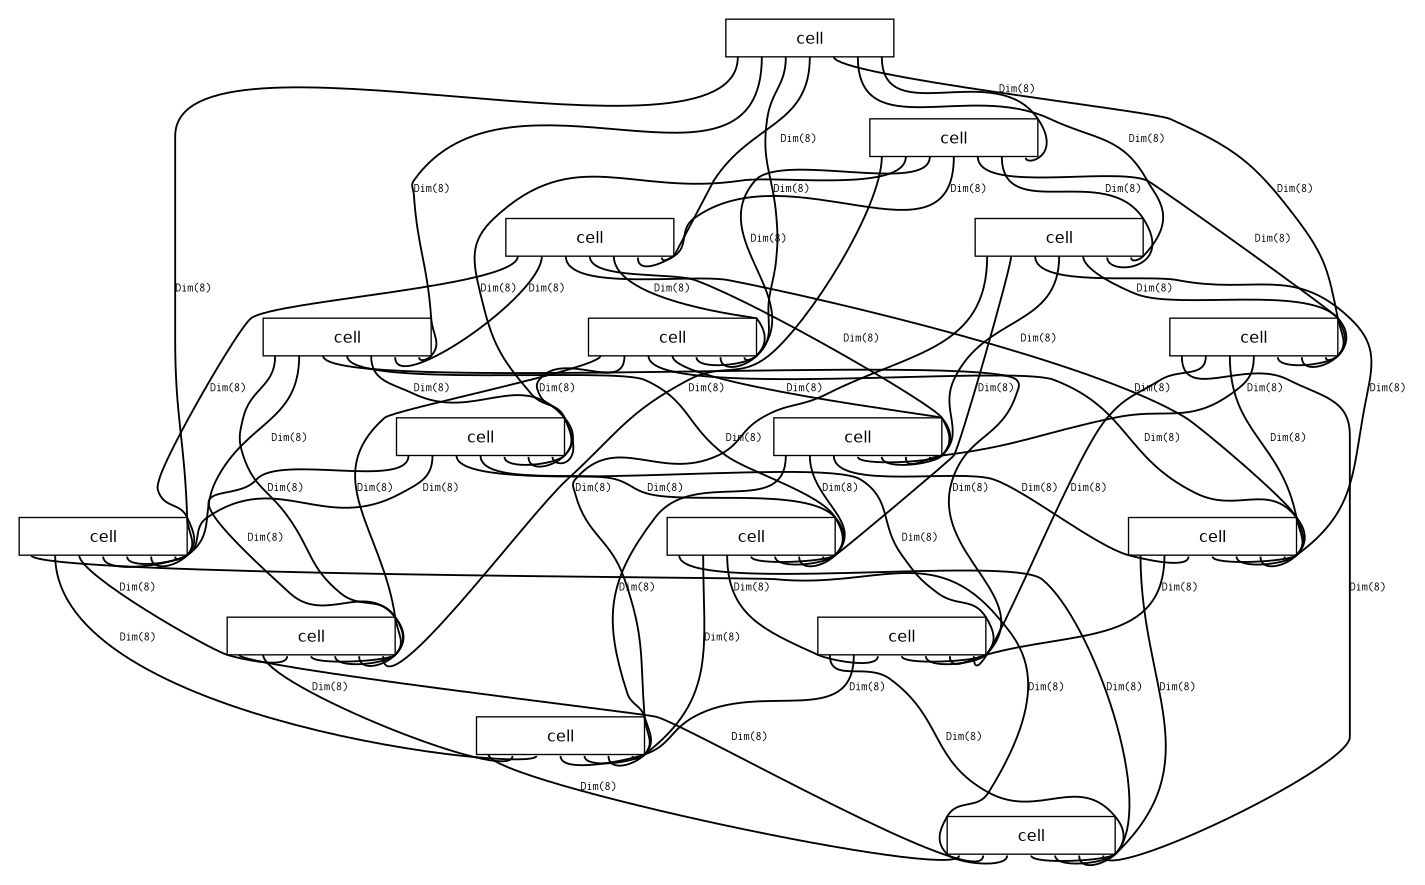

In [9]:
grid.draw()

## From clues to solutions

The clues of a puzzle enter as *initial messages*: each cell's ports start
with a learned embedding of its digit (0 for blank), re-injected at every
round so the clues act as a persistent source. After the last round we read
each cell's state through a linear head, giving one logit per digit.

In [10]:
class SudokuSolver(torch.nn.Module):
    def __init__(self, n=2, dim=8, n_rounds=6):
        super().__init__()
        self.n, self.n_rounds = n, n_rounds
        n_peers = len(sudoku_peers(n)[0])
        self.grid = sudoku(n, dim=dim)
        self.cells = self.grid.as_network().module
        self.embedding = torch.nn.Embedding(n * n + 1, dim)
        self.readout = torch.nn.Linear(n_peers * dim, n * n)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell in range(clues.shape[1]):
            for port in self.grid.box_ports(cell):
                init[port] = embedded[:, cell, :]
        states = self.cells(init=init, n_rounds=self.n_rounds)
        return self.readout(torch.stack(states, dim=1))


model = SudokuSolver().to(device)
sum(p.numel() for p in model.parameters())

12980

## Data

We generate puzzles by backtracking with a shuffled digit order, then blank
random cells. This is a pipeline demo rather than a serious benchmark: 4x4
sudokus only have 288 completed grids, so the point is to watch the graph
neural network learn to propagate constraints, not to compete with solvers.

In [11]:
puzzles = [random_sudoku(n=2, n_clues=8, seed=seed) for seed in range(256)]
train, test = puzzles[:192], puzzles[192:]

clues = torch.tensor([clue for clue, _ in train], device=device)
targets = torch.tensor([solution for _, solution in train], device=device) - 1
test_clues = torch.tensor([clue for clue, _ in test], device=device)

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []

start = time.perf_counter()
for step in range(300):
    batch = torch.randint(0, len(train), (32, ), device=device)
    optimizer.zero_grad()
    logits = model(clues[batch])
    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, 4), targets[batch].reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print(f"trained 300 steps in {time.perf_counter() - start:.1f}s on {device}")

trained 300 steps in 3.8s on cuda


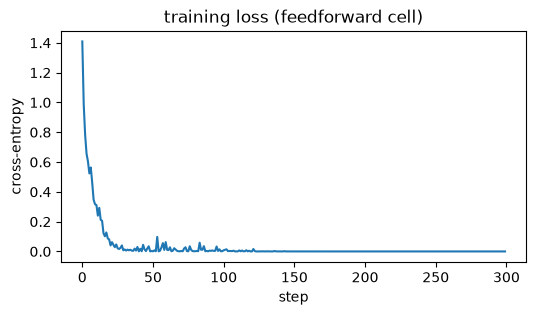

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step"), plt.ylabel("cross-entropy")
plt.title("training loss (feedforward cell)")
plt.show()

## Decoding

`decode_sudoku` keeps the clues fixed and takes the most likely digit for
each blank cell; `check_sudoku` verifies the result against the rules.

In [14]:
def accuracy(model, n=2):
    model.eval()
    with torch.no_grad():
        logits = model(test_clues).cpu()
    decoded = [decode_sudoku(logits[i], test[i][0], n) for i in range(len(test))]
    cell_acc = sum(
        digit == expected
        for grid, (_, solution) in zip(decoded, test)
        for digit, expected in zip(grid, solution)) / ((n * n) ** 2 * len(test))
    solved = sum(check_sudoku(g, n) for g in decoded) / len(test)
    return decoded, cell_acc, solved


decoded, cell_acc, solved = accuracy(model)
print(f"cell accuracy: {cell_acc:.0%}, valid grids: {solved:.0%}")

cell accuracy: 99%, valid grids: 91%


In [15]:
def show(grid):
    return "\n".join(
        " ".join(str(digit) if digit else "." for digit in grid[row:row + 4])
        for row in range(0, 16, 4))


example = next(i for i, grid in enumerate(decoded) if check_sudoku(grid))
print(show(test[example][0]), "\n\n" + show(decoded[example]))

3 . 1 4
1 . . 2
2 . . .
. . 2 3 

3 2 1 4
1 4 3 2
2 3 4 1
4 1 2 3


## Beyond feedforward cells: a recurrent, size-independent cell

Nothing forces the cell to be feedforward. With `state_dim` set, `sudoku`
gives every cell two extra self-wired port pairs — a **state** loop and a
**clue** loop. The state loop is a trace on the box: whatever the cell emits
on its state port arrives back on its own state port next round, so the cell
carries a hidden state through the message passing. `gru_cell` uses it to run
a GRU update from the mean-pooled peer messages and the injected clue, which
propagates constraints more stably over many rounds.

Because the cell reads its number of peers off the input width, its parameters
are **independent of the grid size**: the very same weights run on a 4x4 or a
9x9 grid — only the digit embedding and the read-out head know about $n$.

In [16]:
class RecurrentSudokuSolver(torch.nn.Module):
    def __init__(self, n=2, dim=8, state_dim=16, n_rounds=12):
        super().__init__()
        self.n, self.dim, self.state_dim = n, dim, state_dim
        self.n_rounds = n_rounds
        self.n_peers = len(sudoku_peers(n)[0])
        self.grid = sudoku(n, dim=dim, state_dim=state_dim)
        self.cells = self.grid.as_network().module
        self.embedding = torch.nn.Embedding(n * n + 1, dim)
        self.readout = torch.nn.Linear(state_dim, n * n)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell in range(clues.shape[1]):
            for port in self.grid.box_ports(cell)[-2:]:   # the clue pair
                init[port] = embedded[:, cell, :]
        states = self.cells(init=init, n_rounds=self.n_rounds)
        offset = self.n_peers * self.dim
        hidden = torch.stack(
            [s[:, offset:offset + self.state_dim] for s in states], dim=1)
        return self.readout(hidden)


recurrent = RecurrentSudokuSolver(n=2, dim=8, state_dim=16, n_rounds=12)
cell_params = sum(p.numel() for p in recurrent.grid.parameters())
same_cell_9x9 = sum(
    p.numel() for p in sudoku(n=3, dim=8, state_dim=16).parameters())
print(f"recurrent cell: {cell_params} weights, shared by all "
      f"{len(recurrent.grid.boxes)} cells")
print(f"the same cell on a 9x9 grid: {same_cell_9x9} weights "
      f"(identical: {cell_params == same_cell_9x9})")

recurrent cell: 4808 weights, shared by all 16 cells
the same cell on a 9x9 grid: 4808 weights (identical: True)


In [17]:
recurrent = recurrent.to(device)
optimizer = torch.optim.Adam(recurrent.parameters(), lr=0.005)
losses = []

start = time.perf_counter()
for step in range(400):
    batch = torch.randint(0, len(train), (32, ), device=device)
    optimizer.zero_grad()
    logits = recurrent(clues[batch])
    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, 4), targets[batch].reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

_, cell_acc, solved = accuracy(recurrent)
print(f"trained 400 steps in {time.perf_counter() - start:.1f}s on {device}")
print(f"cell accuracy: {cell_acc:.0%}, valid grids: {solved:.0%}, "
      f"with {sum(p.numel() for p in recurrent.parameters())} parameters")

trained 400 steps in 8.6s on cuda
cell accuracy: 97%, valid grids: 98%, with 4916 parameters


## Where to go from here

Nothing above is specific to 4x4 grids: `sudoku(n=3, dim=...)` gives the
81-cell map with 20 ports per cell, and the recurrent solver above reuses the
exact same cell weights there — given more rounds and a real dataset it trains
on 9x9 puzzles. More generally, `CMap.from_wiring` turns any port-wired
collection of `Network` boxes into a trainable graph neural network — batched
in one flat tensor and running on the GPU — and any `discopy.neural.Diagram`,
built compositionally with cups, caps and swaps, evaluates by message passing
through `to_map()`: string diagrams as neural architectures, with the geometry
of interaction as their operational semantics.